<span style="color:gray; font-size:smaller;">Written by Chang Yun</span>

# Part 6 - Applying motif filters

**Problem**: When aggregating many motifs, any underlying issues grow to become bigger. One problem is **messy, noisy motifs**. Even after a motif discovery algorithm, such as TF-MoDISco, there can still be noisy motifs, that build up as we aggregate motifs - and can ultimately disrupt our analysis. 
(E.g., ~5% noisy motifs: in one Modisco output of 30 motifs = ~1-2 motifs; in 100 x Modisco outputs = **~150** motifs..!)

**Solution**: Here, we use a series of **quantitative motif filters** to flag and remove unwanted motifs.

**Approach**: The general approach to this step is as follows:
- **Step 1**: Determne the types of motfis we do not want
- **Step 2**: Calculate some quantitative metrics to assess "unwantedness"
- **Step 3**: Select a threshold and operation to classify wanted vs. unwanted
- **Step 4**: Flag motifs by applying the threshold
- *(Optional)* **Step 5**: Unflag motifs that should not be removed
- **Step 6**: Remove flagged motifs from MotifCompendium object

**Let's go through each step!**

## 6-1. Archetypes of "unwanted" motif

First, we outline 9 archetypes of noisy, unwanted motifs that we commonly would like to remove:
1. **Single peak**: A single, sharp peak (e.g., __A_)
2. **Random, noisy chaos**: Random noise
3. **Sharp uncertain peaks**: Sharp contribution peaks, but equal across all bases
4. **Broad single nucleotide**: Broad single nucleotide repeats (e.g., AAAAAA)
5. **Broad GC/AT bias**: GC/AT noise, with consistently similar contribution between G/C, A/T
6. **Broad dinucleotide repeats**: Repeated nucleotide pair (e.g., CpG: GCGCGCGC)
7. **Few seqlets**: A motif constructed from too few seqlets
8. **Positive/Negative inverted**: Categorized as a positive/negative pattern by modisco, but sum of contributions is negative/positive
9. **Truncated motif**: Motif is not centered (pushed left/right) and truncated short by window length

Let's look at some examples of each motif below: (Examples are from ENCODE ATAC-seq+DNASE-seq Atlas Chrombpnet CWM motifs)

In [38]:
# Standard MotifCompendium setup
import os
import numpy as np
import pandas as pd
from IPython.display import Image, display
import base64
import gdown

import MotifCompendium

# Set compute options
max_chunk = 1000
max_cpus = 16
use_gpu = True
safe = True
fast_plot = False

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
MotifCompendium.set_compute_options(
    max_chunk=max_chunk,
    max_cpus=max_cpus,
    use_gpu=use_gpu,
    fast_plotting=fast_plot,
)

In [39]:
# Download dataset from Google Drive
file_id = "1JSRf-4YCa5kN3Fhn8aUXVC4OhuPzXqIp"
file_url = f'https://drive.google.com/uc?id={file_id}'
output_path = "data/6_motif_filtering.mc"

gdown.download(file_url, output_path, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1JSRf-4YCa5kN3Fhn8aUXVC4OhuPzXqIp
To: /oak/stanford/groups/akundaje/cmyun/software/motifcompendium/tutorials/data/6_motif_filtering.mc
100%|██████████| 5.27M/5.27M [00:00<00:00, 53.2MB/s]


'data/6_motif_filtering.mc'

In [40]:
# Load example MotifCompendium
output_path = "data/6_motif_filtering.mc"
motif_filtering_mc_path = output_path
mc = MotifCompendium.load(motif_filtering_mc_path, safe=safe)

In [41]:
# Visualize logos
import MotifCompendium.utils.motif as utils_motif

if "logo (fwd)" not in mc.images():
    mc.add_logos(mc.get_standard_motif_stack(), "logo (fwd)", 0)
if "logo (rev)" not in mc.images():
    mc.add_logos(utils_motif.reverse_complement(mc.get_standard_motif_stack()), "logo (rev)", 0)

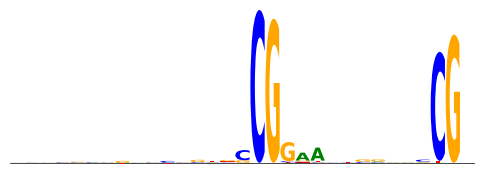

In [42]:
# Archetype #1: Sharp, single peak
mc.sort(
    by='motif_entropy',
    ascending=True,
    inplace=True
)
logo_fwd = mc.get_images('logo (fwd)')
image_bytes = base64.b64decode(logo_fwd[0])
display(Image(data=image_bytes))

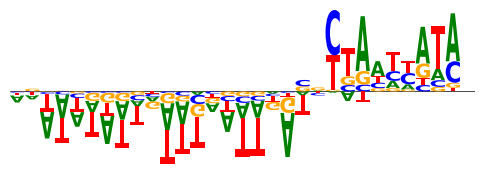

In [43]:
# Archetype #2: Random, noisy chaos
mc.sort(
    by='motif_entropy',
    ascending=False,
    inplace=True
)
logo_fwd = mc.get_images('logo (fwd)')
image_bytes = base64.b64decode(logo_fwd[0])
display(Image(data=image_bytes))

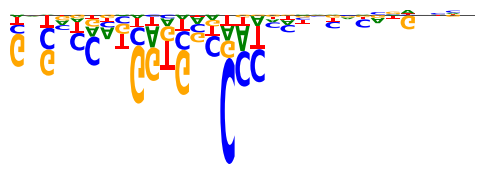

In [44]:
# Archetype #3: Noisy, uncertain peaks
mc.sort(
    by='weighted_base_entropy',
    ascending=False,
    inplace=True
)
logo_fwd = mc.get_images('logo (fwd)')
image_bytes = base64.b64decode(logo_fwd[0])
display(Image(data=image_bytes))

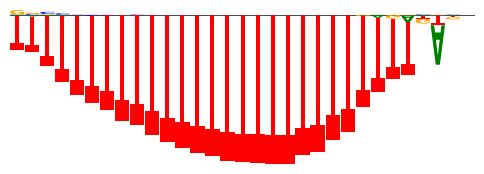

In [45]:
# Archetype #4: Broad single nucleotide
mc.sort(
    by='posbase_entropy_score',
    ascending=False,
    inplace=True
)
logo_fwd = mc.get_images('logo (fwd)')
image_bytes = base64.b64decode(logo_fwd[0])
display(Image(data=image_bytes))

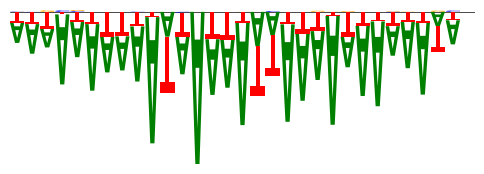

In [46]:
# Archetype #5: Broad GC/AT bias
mc.sort(
    by='copair_entropy_score',
    ascending=False,
    inplace=True
)
logo_fwd = mc.get_images('logo (fwd)')
image_bytes = base64.b64decode(logo_fwd[0])
display(Image(data=image_bytes))

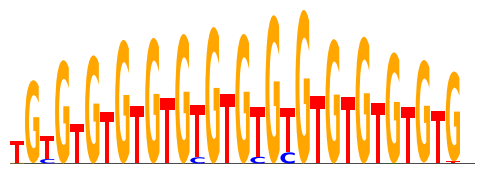

In [47]:
# Archetype #6: Broad dinucleotide repeats
mc.sort(
    by='dinuc_entropy_score',
    ascending=False,
    inplace=True
)
logo_fwd = mc.get_images('logo (fwd)')
image_bytes = base64.b64decode(logo_fwd[0])
display(Image(data=image_bytes))

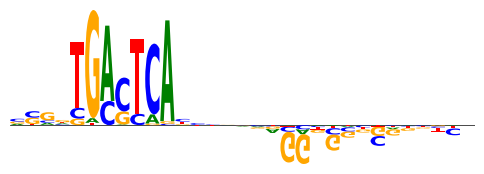

In [48]:
# Archetype #7: Few seqlets
mc.sort(
    by='num_seqlets',
    ascending=True,
    inplace=True
)
logo_fwd = mc.get_images('logo (fwd)')
image_bytes = base64.b64decode(logo_fwd[1])
display(Image(data=image_bytes))

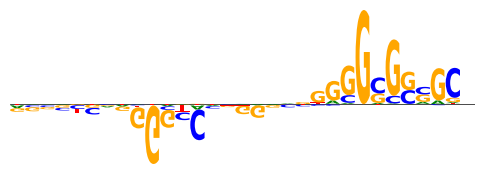

In [49]:
# Archetype #8: Positive/negative inverted
mc.sort(
    by='posneg_inverted',
    ascending=False,
    inplace=True
)
logo_fwd = mc.get_images('logo (fwd)')
image_bytes = base64.b64decode(logo_fwd[0])
display(Image(data=image_bytes))

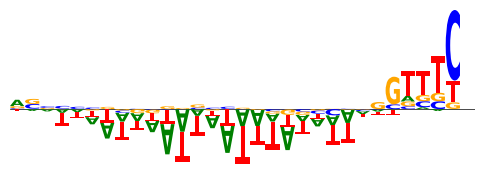

In [50]:
# Archetype #9: Truncated
mc.sort(
    by='truncated',
    ascending=False,
    inplace=True
)
logo_fwd = mc.get_images('logo (fwd)')
image_bytes = base64.b64decode(logo_fwd[0])
display(Image(data=image_bytes))

## 6-2. Motif filter metrics

Next, we outline **11 quantitative metrics** used to identify each archetype:
1. **Motif entropy**: Randomness of motif (Used for Archetype #1 and Archetype #2) (float: [0,1])
2. **Weighted base entropy**: Randomness of each base (A,C,G,T), weighted by contribution (float: [0,1])
3. **Weighted positional entropy**: Randomness of each position (across length, L), weighted by contribution (float: [0,1])
4. **Position-base entropy score**: Position entropy (across length) * (1 - Base entropy (across base)) (float: [0,1])
5. **Copair entropy score**: Position entropy (across length) * (1 - Entropy of co-occuring bases (AC, AG, AT, CA, ...) at each position) (float: [0,1])
6. **Copair composition**: % represented by co-occuring bases (AC, AG, AT, CA, ...) at each position (float: [0,1])
7. **Dinucleotide entropy score**: Position entropy (across length) * (1 - Entropy of dinucleotides (AC, AG, AT, CA, ...) at each 2 bp fixed window) (float: [0,1])
8. **Dinucleotide composition**: % represented by repeated dinucleotides at each 2 bp fixed window (float: [0,1])
9. **Dinucleotide score**: % represented by dinucleotides in 2 bp sliding window (float: [0,1])
6. **Positive/Negative inverted**: Check if positive/negative categorization is inverted (bool)
7. **Truncated**: Check if motif edges have highest contribution (bool)

Many of the metrics are based on **Shannon Entropy** (https://en.wikipedia.org/wiki/Entropy_(information_theory)). For those less familiar with entropy, a general rule of thumb is: Higher entropy = More randomness = More noise = Less signal (E.g., A fair coin toss, p(Head) = p(Tail) = 0.5, has no preference = no signal = just noise).

The benefits of entropy-based metrics are:
- **Numerical**: We can calculate metrics directly from the motif's numerical matrix representations (vs. string matching, for example)
- **Log-scale**: Entropy is on a log scale; therefore outliers are *truly* outliers (helpful for classification, as we will see)
- **Probabilistic**: (Hand-wavy; Still developing exact math) TF-DNA binding is probabilistic. Sequencing assays (e.g., ChIP-seq, ATAC-seq) sample from the underlying probability as read counts. Contribution scores represent the log fold change in counts (vs. a non-binding background) contributed to each base+position. Now, we can expect some characteristics for the underlying TF-DNA binding probability (e.g., reasonable binding site length, some sequence specificity, etc.). These metrics capture these expected characteristics of the underlying probability.

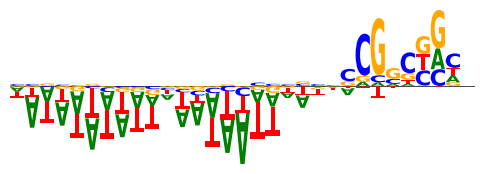

In [51]:
# Example of a "high" entropy motif = random noise
mc.sort(
    by='motif_entropy',
    ascending=False,
    inplace=True
)
logo_fwd = mc.get_images('logo (fwd)')
image_bytes = base64.b64decode(logo_fwd[1])
display(Image(data=image_bytes))

### Calculating motif filter metrics

As part of the MotifCompendium package, we have a built-in function to easily calculate motif filter metrics in one step: `calculate_filters`.

This function takes in (1) the target MotifCompendium object, (2) and a list of motif metrics to calculate, and populates the metadata inside the MotifCompendium object a new column for each motif metric.

First, we define the list of metrics we want to calculate:

In [52]:
# Below are ALL 11 possible motif filter metrics that can be calculated - remove any that are not needed
metric_list = [
    'motif_entropy',
    'weighted_base_entropy',
    'weighted_position_entropy',
    'posbase_entropy_score',
    'copair_entropy_score',
    'copair_composition',
    'dinuc_entropy_score',
    'dinuc_composition',
    'dinuc_score',
    'posneg_inverted',
    'truncated',
]

Next, we pass the MotifCompendium object and the metrics list to `calculate_filters`:

In [53]:
# Calculate selected filters metrics
import MotifCompendium.utils.analysis as utils_analysis

utils_analysis.calculate_filters(
    mc=mc,
    metric_list=metric_list,
)

See that the MotifCompendium object's metadata has been populated with a new column corresponding to each motif metric:

In [54]:
# View calculated metrics
mc.metadata[metric_list]

,motif_entropy,weighted_base_entropy,weighted_position_entropy,posbase_entropy_score,copair_entropy_score,copair_composition,dinuc_entropy_score,dinuc_composition,dinuc_score,posneg_inverted,truncated
0,0.909039,0.773186,0.906237,0.081094,0.079984,0.555862,0.095205,0.384913,0.311822,False,False
1,0.899571,0.743472,0.879355,0.048959,0.098134,0.595945,0.084866,0.358558,0.323394,False,False
2,0.890400,0.706978,0.910388,0.153112,0.300431,0.671783,0.194171,0.488482,0.394038,False,False
3,0.876190,0.701711,0.828626,0.006737,0.009089,0.539826,0.054402,0.356073,0.187097,False,False
4,0.871609,0.671701,0.869645,0.117776,0.274258,0.664537,0.182331,0.414198,0.354788,False,False
...,...,...,...,...,...,...,...,...,...,...,...
66,0.474558,0.171210,0.315355,0.080664,0.104301,0.127399,0.171333,0.666031,0.215229,True,True
67,0.474167,0.158411,0.480224,0.325965,0.157634,0.102180,0.251407,0.470113,0.124644,False,False
68,0.471348,0.149762,0.465508,0.309842,0.090248,0.118970,0.246888,0.493253,0.130282,False,False
69,0.463460,0.140430,0.353742,0.159108,0.021420,0.086751,0.271047,0.885023,0.445758,False,False


## 6-3. Flagging motifs, based on thresholds
Now that we have calculated a quantiative metric for each archetype, we can apply a fixed threshold to classify each motif into flagged vs. not flagged for removal.

As with any classification, the threshold for each metric depends on each user's use case.

Below are some suggested threshold values for BPNet and Chrombpnet TF-MoDISco derived CWM motifs. Users should adjust according to their data specifications.

[**Optional**] Now, we could directly apply a threshold, operation, and flag on to the MotifCompendium metadata table. 

However, to make tracking easier, we're going to organize each threshold with a dataclass, `_FilterArgs`: containing
- name: Filter name
- metric: Filter metric
- operation: Logic operation to apply 
- threshold: Threshold value (float, bool)

In [55]:
# Define filter thresholds and operations
from dataclasses import dataclass, field, asdict
from typing import Union, List, Tuple

@dataclass
class _FilterArgs:
    # INTERNAL: Standard filter arguments
    name: str
    metric: str
    operation: str
    threshold: Union[float, bool]

    def to_dict(self):
        # Return filter arguments as a dictionary
        return asdict(self)

motif_filters = [
    _FilterArgs(
        name="1_singlepeak",
        metric="motif_entropy",
        operation="<",
        threshold=0.35, # Adjust as needed
    ),
    _FilterArgs(
        name="2_noisemix",
        metric="motif_entropy",
        operation=">",
        threshold=0.75, # Adjust as needed
    ),
    _FilterArgs(
        name="3_noisypeaks",
        metric="weighted_base_entropy",
        operation=">",
        threshold=0.6, # Adjust as needed
    ),
    _FilterArgs(
        name="4_broadsingle_1",
        metric="weighted_position_entropy",
        operation=">",
        threshold=0.85, # Adjust as needed
    ),
    _FilterArgs(
        name="4_broadsingle_2",
        metric="posbase_entropy_score",
        operation=">",
        threshold=0.5, # Adjust as needed
    ),
    _FilterArgs(
        name="5_gcbias_1",
        metric="copair_entropy_score",
        operation=">",
        threshold=0.35, # Adjust as needed
    ),
    _FilterArgs(
        name="5_gcbias_2",
        metric="copair_composition",
        operation=">",
        threshold=0.45, # Adjust as needed
    ),
    _FilterArgs(
        name="6_dinucrepeat_1",
        metric="dinuc_entropy_score",
        operation=">",
        threshold=0.5, # Adjust as needed
    ),
    _FilterArgs(
        name="6_dinucrepeat_2",
        metric="dinuc_composition",
        operation=">",
        threshold=0.875, # Adjust as needed
    ),
    _FilterArgs(
        name="6_dinucrepeat_3",
        metric="dinuc_score",
        operation=">",
        threshold=0.45, # Adjust as needed
    ),
    _FilterArgs(
        name="7_minseqlets",
        metric="num_seqlets",
        operation="<",
        threshold=100, # Adjust as needed
    ),
    _FilterArgs(
        name="8_posneg_inverted",
        metric="posneg_inverted",
        operation="==",
        threshold=True,
    ),
    _FilterArgs(
        name="9_truncated",
        metric="truncated",
        operation="==",
        threshold=True,
    ),
]

And we're also going to define a small function, `apply_filter_threshold` to apply each filter on to a MotifCompendium object and create a new flag column:

In [56]:
def apply_filter_threshold(
    mc: MotifCompendium,
    flag_col: str,
    metric: str,
    operation: str,
    threshold: float,
) -> None:
    """
    Apply a filter threshold to the MotifCompendium object.
    
    Args:
        mc (MotifCompendium): The MotifCompendium object.
        flag_col (str): The column name to use for the filter flag.
        metric (str): The metric to use for the filter.
        operation (str): The operation to use for the filter. One of: <, <=, >, >=, ==, !=
        threshold (float): The threshold to use for the filter.
    
    Returns:
        None
    """
    if operation == "<":
        mc[flag_col] = mc[flag_col] | (mc[metric] < threshold)
    elif operation == "<=":
        mc[flag_col] = mc[flag_col] | (mc[metric] <= threshold)
    elif operation == ">":
        mc[flag_col] = mc[flag_col] | (mc[metric] > threshold)
    elif operation == ">=":
        mc[flag_col] = mc[flag_col] | (mc[metric] >= threshold)
    elif operation == "==":
        mc[flag_col] = mc[flag_col] | (mc[metric] == threshold)
    elif operation == "!=":
        mc[flag_col] = mc[flag_col] | (mc[metric] != threshold)
    elif operation == "isna":
        mc[flag_col] = mc[flag_col] | (mc[metric].isna())
    elif operation == "notna":
        mc[flag_col] = mc[flag_col] | (mc[metric].notna())
    else:
        raise ValueError("Invalid operation for filter threshold.")

Let's apply each filter to the MotifCompendium object, and create a new metadata column `flag_remove` to flag for removal:

In [57]:
# Apply all filters
flag_col = "flag_remove"
mc.metadata[flag_col] = False

for filter_args in motif_filters:
    apply_filter_threshold(
        mc=mc,
        flag_col=flag_col,
        metric=filter_args.metric,
        operation=filter_args.operation,
        threshold=filter_args.threshold,
    )

See that the MotifCompendium object's metadata has been populated with the new `flag_remove` column:

In [58]:
# View MotifCompendium
mc

,name,num_seqlets,model,posneg,experiment,assay,tissue,organ,system,motif_entropy,...,posneg_inverted,copair_entropy_ratio,weighted_position_entropy,posbase_entropy_score,copair_entropy_score,copair_composition,dinuc_entropy_score,dinuc_composition,dinuc_score,flag_remove
0,ENCSR925LGW_counts-neg.ENCSR925LGW_ATAC_heart-...,49,ENCSR925LGW_counts,neg,ENCSR925LGW_counts,ATAC,heart,heart,circulatory-system,0.909039,...,False,1.003640,0.906237,0.081094,0.079984,0.555862,0.095205,0.384913,0.311822,True
1,ENCSR000EOS_counts-neg.ENCSR000EOS_DNASE_Jurka...,29,ENCSR000EOS_counts,neg,ENCSR000EOS_counts,DNASE,T-cell,blood,immune-system,0.899571,...,False,1.020618,0.879355,0.048959,0.098134,0.595945,0.084866,0.358558,0.323394,True
2,ENCSR914DOH_counts-neg.ENCSR914DOH_DNASE_heart...,45,ENCSR914DOH_counts,neg,ENCSR914DOH_counts,DNASE,heart,heart,circulatory-system,0.890400,...,False,1.358409,0.910388,0.153112,0.300431,0.671783,0.194171,0.488482,0.394038,True
3,ENCSR531UVE_counts-neg.ENCSR531UVE_DNASE_stimu...,46,ENCSR531UVE_counts,neg,ENCSR531UVE_counts,DNASE,T-cell,blood,immune-system,0.876190,...,False,0.892880,0.828626,0.006737,0.009089,0.539826,0.054402,0.356073,0.187097,True
4,ENCSR926GDT_counts-neg.ENCSR926GDT_ATAC_dendri...,138,ENCSR926GDT_counts,neg,ENCSR926GDT_counts,ATAC,dendritic-cell,blood,immune-system,0.871609,...,False,1.299991,0.869645,0.117776,0.274258,0.664537,0.182331,0.414198,0.354788,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,ENCSR000FDI_counts-neg.ENCSR000FDI_DNASE_HT108...,127,ENCSR000FDI_counts,neg,ENCSR000FDI_counts,DNASE,cancer-cell,connective-tissue,immune-system,0.474558,...,True,0.620557,0.315355,0.080664,0.104301,0.127399,0.171333,0.666031,0.215229,True
67,ENCSR593LTJ_counts-neg.ENCSR593LTJ_DNASE_troph...,446,ENCSR593LTJ_counts,neg,ENCSR593LTJ_counts,DNASE,embryo,embryo,integumental-system,0.474167,...,False,0.772485,0.480224,0.325965,0.157634,0.102180,0.251407,0.470113,0.124644,False
68,ENCSR035QHH_counts-neg.ENCSR035QHH_DNASE_place...,148,ENCSR035QHH_counts,neg,ENCSR035QHH_counts,DNASE,placenta,placenta,reproductive-system,0.471348,...,False,0.615179,0.465508,0.309842,0.090248,0.118970,0.246888,0.493253,0.130282,False
69,ENCSR627UDJ_counts-pos.ENCSR627UDJ_DNASE_T-cel...,1101,ENCSR627UDJ_counts,pos,ENCSR627UDJ_counts,DNASE,T-cell,blood,immune-system,0.463460,...,False,0.674211,0.353742,0.159108,0.021420,0.086751,0.271047,0.885023,0.445758,True


We plan to remove the motifs flagged as `True` in `flag_remove` column:

In [59]:
mc[mc[flag_col]==True]

,name,num_seqlets,model,posneg,experiment,assay,tissue,organ,system,motif_entropy,...,posneg_inverted,copair_entropy_ratio,weighted_position_entropy,posbase_entropy_score,copair_entropy_score,copair_composition,dinuc_entropy_score,dinuc_composition,dinuc_score,flag_remove
0,ENCSR925LGW_counts-neg.ENCSR925LGW_ATAC_heart-...,49,ENCSR925LGW_counts,neg,ENCSR925LGW_counts,ATAC,heart,heart,circulatory-system,0.909039,...,False,1.003640,0.906237,0.081094,0.079984,0.555862,0.095205,0.384913,0.311822,True
1,ENCSR000EOS_counts-neg.ENCSR000EOS_DNASE_Jurka...,29,ENCSR000EOS_counts,neg,ENCSR000EOS_counts,DNASE,T-cell,blood,immune-system,0.899571,...,False,1.020618,0.879355,0.048959,0.098134,0.595945,0.084866,0.358558,0.323394,True
2,ENCSR914DOH_counts-neg.ENCSR914DOH_DNASE_heart...,45,ENCSR914DOH_counts,neg,ENCSR914DOH_counts,DNASE,heart,heart,circulatory-system,0.890400,...,False,1.358409,0.910388,0.153112,0.300431,0.671783,0.194171,0.488482,0.394038,True
3,ENCSR531UVE_counts-neg.ENCSR531UVE_DNASE_stimu...,46,ENCSR531UVE_counts,neg,ENCSR531UVE_counts,DNASE,T-cell,blood,immune-system,0.876190,...,False,0.892880,0.828626,0.006737,0.009089,0.539826,0.054402,0.356073,0.187097,True
4,ENCSR926GDT_counts-neg.ENCSR926GDT_ATAC_dendri...,138,ENCSR926GDT_counts,neg,ENCSR926GDT_counts,ATAC,dendritic-cell,blood,immune-system,0.871609,...,False,1.299991,0.869645,0.117776,0.274258,0.664537,0.182331,0.414198,0.354788,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,ENCSR729FNL_counts-pos.ENCSR729FNL_ATAC_poster...,852,ENCSR729FNL_counts,pos,ENCSR729FNL_counts,ATAC,brain,brain,central-nervous-system,0.536801,...,False,0.781753,0.505437,0.276495,0.063204,0.047968,0.477642,0.948170,0.467438,True
60,ENCSR146KFX_counts-pos.ENCSR146KFX_DNASE_astro...,586,ENCSR146KFX_counts,pos,ENCSR146KFX_counts,DNASE,neural-cell,brain,central-nervous-system,0.488087,...,False,0.927563,0.431407,0.233116,0.088866,0.096556,0.268742,0.902921,0.468010,True
61,ENCSR117PYB_counts-pos.ENCSR117PYB_ATAC_heart-...,87,ENCSR117PYB_counts,pos,ENCSR117PYB_counts,ATAC,heart,heart,circulatory-system,0.484686,...,False,1.041445,0.423771,0.231757,0.249244,0.073397,0.258968,0.841078,0.436605,True
62,ENCSR000FDI_counts-neg.ENCSR000FDI_DNASE_HT108...,127,ENCSR000FDI_counts,neg,ENCSR000FDI_counts,DNASE,cancer-cell,connective-tissue,immune-system,0.474558,...,True,0.620557,0.315355,0.080664,0.104301,0.127399,0.171333,0.666031,0.215229,True


## 6-4. (Optional) Reviving motifs: Based on annotation with reference motifs

As with any classification problem, we wish there was a *one-size-fits-all* solution. However, this is never the case... :(

Some "real" motifs are inherently very close to our "unwanted" motifs. Let's look at some examples from some popular and well-established motif databases: JASPAR (v2024, CORE HUMAN) and HOCOMOCO (V13, CORE).

In [60]:
# Read external TF motif database: JASPAR 2024 CORE (HUMAN), HOCOMOCO V13 CORE
import MotifCompendium.utils.motif as utils_motif
import MotifCompendium.utils.analysis as utils_analysis

# Build reference MotifCompendium
reference_path = os.path.join("..", "pipeline", "data", "HUMAN-JASPAR2024-HOCOMOCOv13.meme.txt")
reference_source = "HUMAN-JASPAR2024-HOCOMOCOv13"
mc_ref_examples = MotifCompendium.build_from_pfm(
    pfm_dict={reference_source: reference_path},
    safe=safe,
)

/oak/stanford/groups/akundaje/cmyun/software/motifcompendium/MotifCompendium/MotifCompendium.py:579: RuntimeWarning: self.alignment_rc is not symmetric. This may be due to numerical instability (especially if you have very symmetric motifs).
  warnings.warn(
/oak/stanford/groups/akundaje/cmyun/software/motifcompendium/MotifCompendium/MotifCompendium.py:599: RuntimeWarning: self.alignment_h should be symmetric for reverse complement motifs and skew-symmetric for motifs that are already aligned, but it is not. This is very rare and should not occur (unless you are working with PFMs, for which it happens often).
  warnings.warn(


In [61]:
# Some examples
example_names = [
    f'{reference_source}-JASP.MA0079.2.SP1',
    f'{reference_source}-HOCO.SP1.H13CORE.2.P.B',
    f'{reference_source}-JASP.MA0506.1.NRF1',
    f'{reference_source}-HOCO.MBD1.H13CORE.0.PSIB.A',
]
mc_ref_examples = mc_ref_examples[mc_ref_examples['name'].isin(example_names)]
mc_ref_examples.metadata['posneg'] = utils_motif.motif_posneg_sum(mc_ref_examples.get_standard_motif_stack())
mc_ref_examples.add_logos(mc_ref_examples.get_standard_motif_stack(), "logo (fwd)", 0)
mc_ref_examples.add_logos(utils_motif.reverse_complement(mc_ref_examples.get_standard_motif_stack()), "logo (rev)", 0)

# Calculate filter metrics
utils_analysis.calculate_filters(
    mc=mc_ref_examples,
    metric_list=metric_list,
)

### Example #1: SP1 (vs. Broad single nucleotide)

The canonical motif for SP1 (and other SP family TFs) is shaped with an inherently broad G/C. (Mechanistically, the TFs likely borrow from the GC's high ΔG binding energy) Therefore, when filtering for **Archetype #4: Broad single nucleotide**, it commonly gets caught out erroneously (false negative):

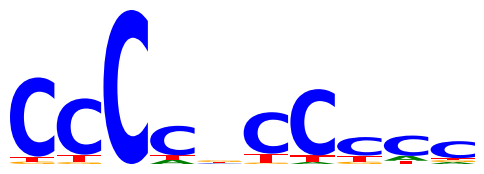

In [62]:
# Example #1: SP1 motif (vs. Broad single nucleotide)
idx = mc_ref_examples.metadata.index[mc_ref_examples['name'] == f'{reference_source}-JASP.MA0079.2.SP1'][0]
logo_fwd = mc_ref_examples.get_images('logo (fwd)')
image_bytes = base64.b64decode(logo_fwd[idx])
display(Image(data=image_bytes))

Calculating our designated metric `posbase_entropy_score`, we see that the canonical motif has an intrisically high entropy:

In [63]:
mc_ref_examples[mc_ref_examples['name'] == f'{reference_source}-JASP.MA0079.2.SP1'].metadata[["name", "posbase_entropy_score"]]

,name,posbase_entropy_score
0,HUMAN-JASPAR2024-HOCOMOCOv13-JASP.MA0079.2.SP1,0.369416


### Example #2: NRF1

Another example is NRF1 (and other NRF family TFs). The canonical motif contains highly rich CpG repeats. Therefore, it often gets caught out by our filter for **Archetype #6: Broad dinucleotide repeats**:

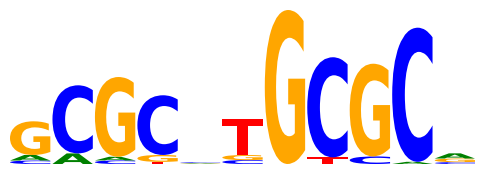

In [64]:
# Example #2: SP1 motif (vs. Broad single nucleotide)
idx = mc_ref_examples.metadata.index[mc_ref_examples['name'] == f'{reference_source}-JASP.MA0506.1.NRF1'][0]
logo_fwd = mc_ref_examples.get_images('logo (fwd)')
image_bytes = base64.b64decode(logo_fwd[idx])
display(Image(data=image_bytes))

Calculating our designated metric `dinuc_entropy_score`, we see that the canonical motif has an intrisically high entropy:

In [65]:
mc_ref_examples[mc_ref_examples['name'] == f'{reference_source}-JASP.MA0506.1.NRF1'].metadata[["name", "dinuc_entropy_score"]]

,name,dinuc_entropy_score
0,HUMAN-JASPAR2024-HOCOMOCOv13-JASP.MA0506.1.NRF1,0.348729


### Reviving false negative motifs

To prevent these "false negatives" (real motif, erroneously flagged for removal), we can use our **motif annotation** tool (for more detail, refer to **Tutorial #5: Motif annotation**):
- **Step 1**: Identify the best match to a known database motif, and its highest similarity score
- **Step 2**: Apply a threshold to revive flagged motifs, if match is good enough

Let's annotate our motifs using the same motif database: JASPAR (2024, CORE HUMAN) and HOCOMOCO (V13, CORE)

In [66]:
# Annotate MotifCompendium with reference motifs
import MotifCompendium.utils.analysis as utils_analysis

reference_path = os.path.join("..", "pipeline", "data", "HUMAN-JASPAR2024-HOCOMOCOv13.meme.txt")
reference_col = "JASP.HOCOMOCO"
reference_score = f"{reference_col}_score0"
reference_name = f"{reference_col}_name0"
reference_logo = f"{reference_col}_logo0"

utils_analysis.assign_label_from_pfms(
    mc=mc,
    pfm_file=reference_path,
    save_col_prefix=reference_col,
)

See that the MotifCompendium object's metadata has been populated with a new annotation column `JASP.HOCOMOCO`:

In [67]:
# View column: JASP.HOCOMOCO
mc.metadata[["name", f"{reference_col}_name0", f"{reference_col}_score0"]]

,name,JASP.HOCOMOCO_name0,JASP.HOCOMOCO_score0
0,ENCSR925LGW_counts-neg.ENCSR925LGW_ATAC_heart-...,HOCO.ZNF26.H13CORE.0.P.B,0.582501
1,ENCSR000EOS_counts-neg.ENCSR000EOS_DNASE_Jurka...,HOCO.ZN613.H13CORE.0.P.C,0.564824
2,ENCSR914DOH_counts-neg.ENCSR914DOH_DNASE_heart...,HOCO.ARX.H13CORE.0.S.B,0.659765
3,ENCSR531UVE_counts-neg.ENCSR531UVE_DNASE_stimu...,HOCO.MBD1.H13CORE.0.PSIB.A,0.604636
4,ENCSR926GDT_counts-neg.ENCSR926GDT_ATAC_dendri...,HOCO.NKX61.H13CORE.0.PS.A,0.609734
...,...,...,...
66,ENCSR000FDI_counts-neg.ENCSR000FDI_DNASE_HT108...,HOCO.BATF.H13CORE.0.P.B,0.919609
67,ENCSR593LTJ_counts-neg.ENCSR593LTJ_DNASE_troph...,HOCO.ZN320.H13CORE.1.P.B,0.918523
68,ENCSR035QHH_counts-neg.ENCSR035QHH_DNASE_place...,HOCO.ZN320.H13CORE.1.P.B,0.920775
69,ENCSR627UDJ_counts-pos.ENCSR627UDJ_DNASE_T-cel...,HOCO.MYCN.H13CORE.1.M.C,0.975531


We will revive any motifs with a similarity greater than `0.9` (can adjust as needed!) with any motif from JASPAR and HOCOMOCO. Let's see what we revived!

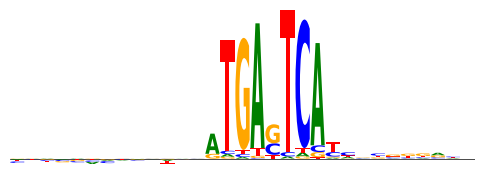

Matched JASP.HOCOMOCO motif: JASP.MA0477.1.FOSL1
motif_entropy                0.587114
weighted_base_entropy        0.320175
weighted_position_entropy    0.427943
posbase_entropy_score        0.015566
copair_entropy_score         0.012705
copair_composition           0.155775
dinuc_entropy_score           0.18232
dinuc_composition            0.461969
dinuc_score                  0.213974
posneg_inverted                  True
truncated                       False
Name: 0, dtype: object


In [68]:
# Revive motifs with similarity greater than threshold
similarity_threshold = 0.9 # Adjust as needed

mc_revived = mc[(mc.metadata[reference_score] > similarity_threshold) & (mc.metadata[flag_col] == True)]
mc_revived.sort(by=reference_score, ascending=False, inplace=True)

# Visualize revived motif #1
logo_fwd = mc_revived.get_images('logo (fwd)')
image_bytes = base64.b64decode(logo_fwd[0])
display(Image(data=image_bytes))
print(f"Matched JASP.HOCOMOCO motif: {mc_revived.metadata[reference_name][0]}")
print(f"{mc_revived.metadata.iloc[0][metric_list]}")

So it looks like we revived a **FOS motif** (matched with a known JASPAR FOSL1 motif), that had been flagged by the `posneg` metric because TF-MoDISco had identified it as a negative motif, despite having (significantly) larger positive contributions (weird..!)

OK, now let's formally revert all flags to revive these false negatives:

In [69]:
print(f"Previously flagged motif #: {mc.metadata[flag_col].sum()}")
mc[flag_col] = (mc[flag_col]) & (mc[reference_score] < similarity_threshold)
print(f"Currently flagged motif #: {mc.metadata[flag_col].sum()}")
print(f"Revived motif #: {mc_revived.metadata[flag_col].sum()}")

Previously flagged motif #: 64
Currently flagged motif #: 46
Revived motif #: 18


### (Caution) Sometimes database motifs are not all good either...

However, not all database motifs are necessarily perfect... As we expand to more "experimental" motif databases, beware: They may not all be "real"!

The motif filter metrics could actually help sort database metrics too (although how to add back real motifs..? A catch-22 problem...)

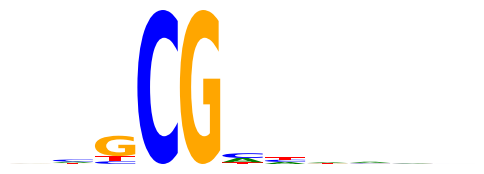

In [70]:
# Example: (Potentially) Bad database motifs
idx = mc_ref_examples.metadata.index[mc_ref_examples['name'] == f"{reference_source}-HOCO.MBD1.H13CORE.0.PSIB.A"][0]
logo_fwd = mc_ref_examples.get_images('logo (fwd)')
image_bytes = base64.b64decode(logo_fwd[idx])
display(Image(data=image_bytes))

Calculating our designated metric `motif_entropy`, we *could* have caught this one out (by low entropy):

In [71]:
mc_ref_examples[mc_ref_examples['name'] == f"{reference_source}-HOCO.MBD1.H13CORE.0.PSIB.A"].metadata[["name", "motif_entropy"]]

,name,motif_entropy
0,HUMAN-JASPAR2024-HOCOMOCOv13-HOCO.MBD1.H13CORE...,0.278712


## 6-5. Removing flagged motifs

Final step: Let's formally remove those flagged motifs. We recommend dividing the original MotifCompendium object into (1) filter passed and (2) removed, in case we ever need to revisit the removed motifs.

In [72]:
# Divide out MotifCompendium into (1) filtered MotifCompendium and (2) removed MotifCompendium
mc_filtered = mc[~mc.metadata[flag_col]]
mc_filtered

,name,num_seqlets,model,posneg,experiment,assay,tissue,organ,system,motif_entropy,...,weighted_position_entropy,posbase_entropy_score,copair_entropy_score,copair_composition,dinuc_entropy_score,dinuc_composition,dinuc_score,flag_remove,JASP.HOCOMOCO_score0,JASP.HOCOMOCO_name0
0,ENCSR117PYB_counts-neg.ENCSR117PYB_ATAC_heart-...,401,ENCSR117PYB_counts,neg,ENCSR117PYB_counts,ATAC,heart,heart,circulatory-system,0.731454,...,0.933696,0.723669,0.510996,0.104321,0.702214,0.548491,0.199857,False,0.924506,HOCO.ZN362.H13CORE.0.P.C
1,ENCSR999NKW_counts-neg.ENCSR999NKW_ATAC_prosta...,238,ENCSR999NKW_counts,neg,ENCSR999NKW_counts,ATAC,prostate-gland,prostate-gland,reproductive-system,0.730949,...,0.954817,0.791284,0.663331,0.094351,0.773063,0.519134,0.181518,False,0.944140,HOCO.ZN362.H13CORE.0.P.C
2,ENCSR096BPX_counts-neg.ENCSR096BPX_ATAC_esopha...,362,ENCSR096BPX_counts,neg,ENCSR096BPX_counts,ATAC,esophagus,esophagus,digestive-system,0.724542,...,0.947505,0.790768,0.532931,0.074009,0.774283,0.500218,0.159382,False,0.958651,HOCO.ZN362.H13CORE.0.P.C
3,ENCSR773USD_counts-neg.ENCSR773USD_ATAC_body-o...,228,ENCSR773USD_counts,neg,ENCSR773USD_counts,ATAC,pancreas,pancreas,endocrine-system,0.705061,...,0.932400,0.820637,0.244758,0.032480,0.827569,0.500526,0.055189,False,0.938012,HOCO.ZN362.H13CORE.0.P.C
4,ENCSR831KAH_counts-neg.ENCSR831KAH_ATAC_tibial...,82,ENCSR831KAH_counts,neg,ENCSR831KAH_counts,ATAC,nerve,nerve,peripheral-nervous-system,0.699899,...,0.939058,0.856467,0.265234,0.028378,0.861664,0.500480,0.027036,False,0.940258,HOCO.ZN362.H13CORE.0.P.C
5,ENCSR373TDL_counts-neg.ENCSR373TDL_ATAC_right-...,240,ENCSR373TDL_counts,neg,ENCSR373TDL_counts,ATAC,liver,liver,digestive-system,0.698179,...,0.886625,0.733647,0.176886,0.025438,0.803215,0.507443,0.044827,False,0.926167,HOCO.ZN362.H13CORE.0.P.C
6,ENCSR113MBR_counts-neg.ENCSR113MBR_ATAC_adrena...,20,ENCSR113MBR_counts,neg,ENCSR113MBR_counts,ATAC,adrenal-gland,adrenal-gland,endocrine-system,0.695681,...,0.575091,0.006869,0.096879,0.321635,0.141369,0.433158,0.179215,False,0.940506,JASP.MA0477.1.FOSL1
7,ENCSR210NKB_counts-neg.ENCSR210NKB_ATAC_testis...,213,ENCSR210NKB_counts,neg,ENCSR210NKB_counts,ATAC,testis,testis,reproductive-system,0.690627,...,0.873932,0.713530,0.196081,0.039044,0.763006,0.491398,0.059132,False,0.901770,HOCO.ZN362.H13CORE.0.P.C
8,ENCSR493IAY_counts-pos.ENCSR493IAY_DNASE_hemat...,99,ENCSR493IAY_counts,pos,ENCSR493IAY_counts,DNASE,blood,blood,immune-system,0.682164,...,0.876408,0.736320,0.185306,0.043080,0.762530,0.499349,0.053957,False,0.927574,HOCO.ZN362.H13CORE.0.P.C
9,ENCSR260UJJ_counts-neg.ENCSR260UJJ_DNASE_T-hel...,189,ENCSR260UJJ_counts,neg,ENCSR260UJJ_counts,DNASE,T-cell,blood,immune-system,0.682126,...,0.876063,0.731313,0.250992,0.044415,0.758959,0.493808,0.070121,False,0.918927,HOCO.ZN362.H13CORE.0.P.C


In [73]:
# Removed motifs: MotifCompendium
mc_removed = mc[mc.metadata[flag_col]]
mc_removed

,name,num_seqlets,model,posneg,experiment,assay,tissue,organ,system,motif_entropy,...,weighted_position_entropy,posbase_entropy_score,copair_entropy_score,copair_composition,dinuc_entropy_score,dinuc_composition,dinuc_score,flag_remove,JASP.HOCOMOCO_score0,JASP.HOCOMOCO_name0
0,ENCSR925LGW_counts-neg.ENCSR925LGW_ATAC_heart-...,49,ENCSR925LGW_counts,neg,ENCSR925LGW_counts,ATAC,heart,heart,circulatory-system,0.909039,...,0.906237,0.081094,0.079984,0.555862,0.095205,0.384913,0.311822,True,0.582501,HOCO.ZNF26.H13CORE.0.P.B
1,ENCSR000EOS_counts-neg.ENCSR000EOS_DNASE_Jurka...,29,ENCSR000EOS_counts,neg,ENCSR000EOS_counts,DNASE,T-cell,blood,immune-system,0.899571,...,0.879355,0.048959,0.098134,0.595945,0.084866,0.358558,0.323394,True,0.564824,HOCO.ZN613.H13CORE.0.P.C
2,ENCSR914DOH_counts-neg.ENCSR914DOH_DNASE_heart...,45,ENCSR914DOH_counts,neg,ENCSR914DOH_counts,DNASE,heart,heart,circulatory-system,0.890400,...,0.910388,0.153112,0.300431,0.671783,0.194171,0.488482,0.394038,True,0.659765,HOCO.ARX.H13CORE.0.S.B
3,ENCSR531UVE_counts-neg.ENCSR531UVE_DNASE_stimu...,46,ENCSR531UVE_counts,neg,ENCSR531UVE_counts,DNASE,T-cell,blood,immune-system,0.876190,...,0.828626,0.006737,0.009089,0.539826,0.054402,0.356073,0.187097,True,0.604636,HOCO.MBD1.H13CORE.0.PSIB.A
4,ENCSR926GDT_counts-neg.ENCSR926GDT_ATAC_dendri...,138,ENCSR926GDT_counts,neg,ENCSR926GDT_counts,ATAC,dendritic-cell,blood,immune-system,0.871609,...,0.869645,0.117776,0.274258,0.664537,0.182331,0.414198,0.354788,True,0.609734,HOCO.NKX61.H13CORE.0.PS.A
5,ENCSR524CPZ_counts-neg.ENCSR524CPZ_ATAC_HG0279...,45,ENCSR524CPZ_counts,neg,ENCSR524CPZ_counts,ATAC,lymphoblast,blood,immune-system,0.870442,...,0.861642,0.102726,0.159617,0.555661,0.135897,0.419964,0.330505,True,0.602447,HOCO.ZN716.H13CORE.0.P.C
6,ENCSR734VFU_counts-neg.ENCSR734VFU_DNASE_stimu...,53,ENCSR734VFU_counts,neg,ENCSR734VFU_counts,DNASE,T-cell,blood,immune-system,0.866716,...,0.824791,0.027912,0.032812,0.496950,0.076767,0.324762,0.267221,True,0.702043,HOCO.MBD1.H13CORE.0.PSIB.A
7,ENCSR395EZY_counts-neg.ENCSR395EZY_DNASE_place...,79,ENCSR395EZY_counts,neg,ENCSR395EZY_counts,DNASE,placenta,placenta,reproductive-system,0.864333,...,0.873355,0.149775,0.353915,0.716441,0.217101,0.426730,0.397514,True,0.628946,HOCO.ZN613.H13CORE.0.P.C
8,ENCSR535NOD_counts-neg.ENCSR535NOD_ATAC_dendri...,62,ENCSR535NOD_counts,neg,ENCSR535NOD_counts,ATAC,dendritic-cell,blood,immune-system,0.862957,...,0.897201,0.211097,0.403103,0.666309,0.230514,0.449862,0.413151,True,0.663327,HOCO.PO4F2.H13CORE.0.S.B
9,ENCSR131CHJ_counts-neg.ENCSR131CHJ_ATAC_dendri...,47,ENCSR131CHJ_counts,neg,ENCSR131CHJ_counts,ATAC,dendritic-cell,blood,immune-system,0.862913,...,0.857118,0.118075,0.193407,0.549766,0.154005,0.453849,0.344319,True,0.641470,HOCO.NKX61.H13CORE.0.PS.A


And that's it! Now we have a set of **good-looking, clean looking motifs**! 🎉

## 6-6. Additional notes: Filtering motifs vs. clusters, Hard filters

### 1. Filtering motifs vs. clusters

In this example, we filtered TF-MoDISco motifs. However, we can also similarly filter **averaged clusters**. Or, even **both**!

Filtering averaged clusters works the same way:
- **Step 1**: Determne the types of clusters we do not want
- **Step 2**: Calculate the filters metrics to assess "unwantedness"
- **Step 3**: Select a threshold and operation to classify wanted vs. unwanted clusters
- **Step 4**: Flag clusters by applying the threshold
- *(Optional)* **Step 5**: Unflag clusters that should not be removed
- **Step 6**: Remove flagged clusters from MotifCompendium object

Somethings to note:
- Averaged clusters do not automatically have a **positive / negative** pattern assigned. Therefore, using metric `posneg` may throw an error.
- We suggest filtering **both motifs AND clusters**, for different reasons:
    - Motifs: During clustering, noisy motifs can potentially create aritifical nodes between discrete motifs - potentially creating larger clusters than expected. 
    - Motifs: A reduced motif set will run faster at every step: similarity calculation, clustering, visualization
    - Clusters: After clustering, depending on the clustering algorithm, spurious clusters may form (e.g., Leiden algorithm using modularity). Good practice to remove them for a final, clean set of clusters.

### 2. Hard filters

As we saw, even well-curated motif databases can contain incorrect motifs. To prevent this, we suggest applying a "**hard filter**" with a higher, very conservative threshold values that are **not revived** by a motif database.

Again, a hard filter works the same way - just don't flip the flag when matching with a motif database!